In [1]:
from mcdata_io import load_signal_and_background

In [3]:
TTLJ, Vcb = load_signal_and_background(
    ttlj_spec='/data6/Users/yeonjoon/VcbMVAStudy/TabNet_template/NvMESample/2017/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree',
    vcb_spec='/data6/Users/yeonjoon/VcbMVAStudy/TabNet_template/NvMESample/2017/Vcb_TTLJ_WtoCB_powheg.root:Mu/Central/Result_Tree',
    mode='b',
    branch_name='template_score_6Class',
    )

Discovered 6 classes from /data6/Users/yeonjoon/VcbMVAStudy/TabNet_template/NvMESample/2017/Vcb_TTLJ_powheg.root:Mu/Central/Result_Tree


In [7]:
import numpy as np

def _logsumexp_np(a: np.ndarray, axis: int | None = None, keepdims: bool = False) -> np.ndarray:
    """Stable log-sum-exp in NumPy only."""
    a = np.asarray(a, dtype=np.float64)
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    if not keepdims and axis is not None:
        out = np.squeeze(out, axis=axis)
    return out

def log_prob_to_temp_prob_np(log_prob: np.ndarray,
                             temperature: float | np.ndarray,
                             axis: int = -1,
                             eps: float = 1e-12) -> np.ndarray:
    """
    log_prob: (..., K) 형태의 로그확률 (log-softmax 출력 가정)
    temperature: 스칼라 또는 log_prob와 브로드캐스트 가능한 텐서(>0)
      - 예) 스칼라 τ, 배치별 τ: (N,1), 클래스별 τ: (1,K) 등
    axis: 소프트맥스 정규화 축 (보통 -1)
    반환: 같은 shape, 지정 축 합=1인 확률
    """
    log_prob = np.asarray(log_prob, dtype=np.float64)
    temperature = np.asarray(temperature, dtype=log_prob.dtype)
    temperature = np.clip(temperature, eps, None)              # τ>0 보장

    scaled = log_prob / temperature                            # logits / τ
    logZ = _logsumexp_np(scaled, axis=axis, keepdims=True)     # 안정적 정규화
    prob = np.exp(scaled - logZ)
    return prob

In [35]:
prob_Vcb = {}
prob_TTLJ = {}
stacked_Vcb = np.vstack([Vcb[f'template_score_6Class_log_prob_{i}'] for i in range(6)]).T
stacked_TTLJ = np.vstack([TTLJ[f'template_score_6Class_log_prob_{i}'] for i in range(6)]).T
for T in [0.5, 0.7 ,1.0, 1.3, 1.5, 2.0, 3.0, 5.0, 10.0, 100.0]:
    prob_Vcb[T] = log_prob_to_temp_prob_np(stacked_Vcb, T, axis=-1)
    prob_TTLJ[T] = log_prob_to_temp_prob_np(stacked_TTLJ, T, axis=-1)

In [36]:
import matplotlib.pyplot as plt
from typing import Dict, List, Optional
import mplhep as hep

def plot_signal_score(
    p_sig_v: Dict[str, np.ndarray],
    p_sig_b: Dict[str, np.ndarray],
    outdir: str,
    bins: int = 100,
    thr: Optional[float] = None,
    tag: str = "",
    sig_idx: List[int] = [0],
    *,
    use_mplhep: bool = True,
    cms_label: str = "Preliminary",   # "Preliminary", "Work in progress", "" 등
    data: bool = False,                # 데이터(True) / 시뮬(False) 표기
    year: Optional[int] = None,       # 2016/17/18/2022/2023 등
    lumi: Optional[float] = None,     # pb^-1 or fb^-1 (lumi_unit으로 단위 표기)
    lumi_unit: str = "fb$^{-1}$",     # "fb$^{-1}$" 또는 "pb$^{-1}$"
    figsize=(14, 10),
    xlim=(0.0, 1.0),
) -> str:
    """
    P_w(sig|x) 분포를 Vcb vs TTLJ로 겹쳐 그림 (density=True).
    - Vcb, TTLJ: {'weight_base': ..., 기타 필요한 내용} 사전
    - w: [K] 또는 [K,] 가중치 (양수); 내부에서 log로 변환
    - sig_idx: 시그널 클래스를 하나 이상 지정 (ex. [0] 또는 [0,3])
    """

    # 스타일: mplhep CMS
    if use_mplhep:
        try:
            hep.style.use(hep.style.CMS)   # 최신 버전 권장
        except Exception:
            hep.style.use("CMS")           # 구버전 호환


    w_v = Vcb["weight_base"].astype(np.float64, copy=False)
    w_b = TTLJ["weight_base"].astype(np.float64, copy=False)

    fig, ax = plt.subplots(figsize=figsize)

    # 가중-정규화(density=True) step-hist
    ax.hist(p_sig_b, bins=bins, weights=w_b, histtype="step",
            density=False, label="Bkg TTLJ  $P_w(\\mathrm{sig}\\,|\\,x)$")
    ax.hist(p_sig_v, bins=bins, weights=w_v, histtype="step",
            density=False, label="Sig Vcb   $P_w(\\mathrm{sig}\\,|\\,x)$")

    ax.set_xlabel(r"$P_w(\mathrm{sig}\,|\,x)$")
    ax.set_ylabel("Event Yield (normalized)")
    ax.set_yscale("log")
    if xlim is not None:
        ax.set_xlim(*xlim)

    # best_thr 수직선
    if thr is not None and 0.0 <= thr <= 1.0:
        ymin, ymax = ax.get_ylim()
        ax.axvline(thr, linestyle="--")
        ax.text(thr, ymax * 0.95, f"thr={thr:.3g}", rotation=90,
                va="top", ha="right")

    ax.legend(loc="best", frameon=False)

    # CMS 라벨 (mplhep)
    if use_mplhep:
        try:
            # 최신 API
            hep.cms.label(cms_label, data=data, year=year, lumi=lumi,
                          lumi_unit=lumi_unit, ax=ax)
        except Exception:
            # 구버전 fallback
            hep.cms.text(cms_label, ax=ax, loc=0)

    plt.tight_layout()
    plt.show()

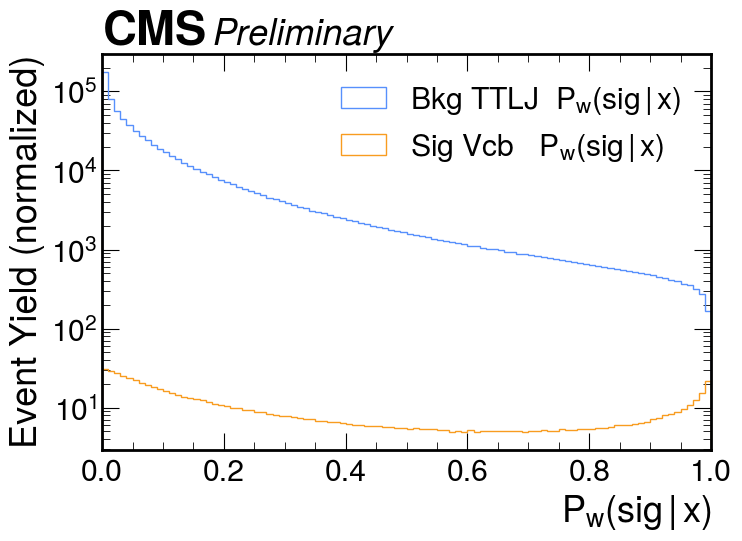

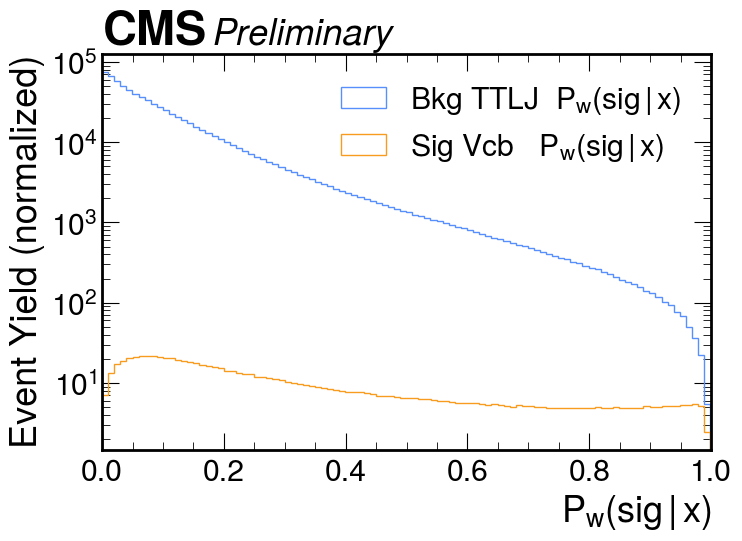

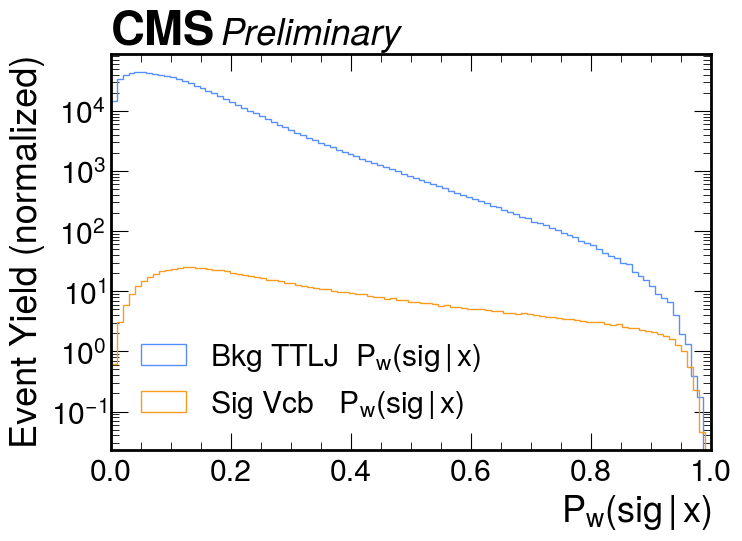

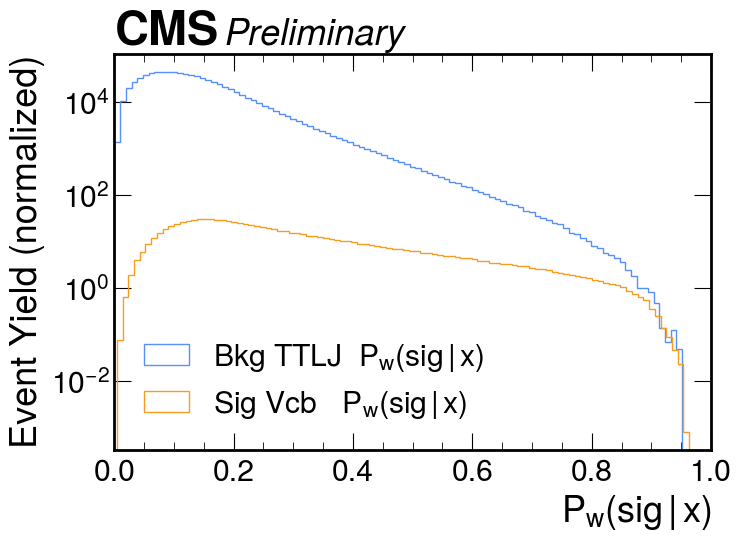

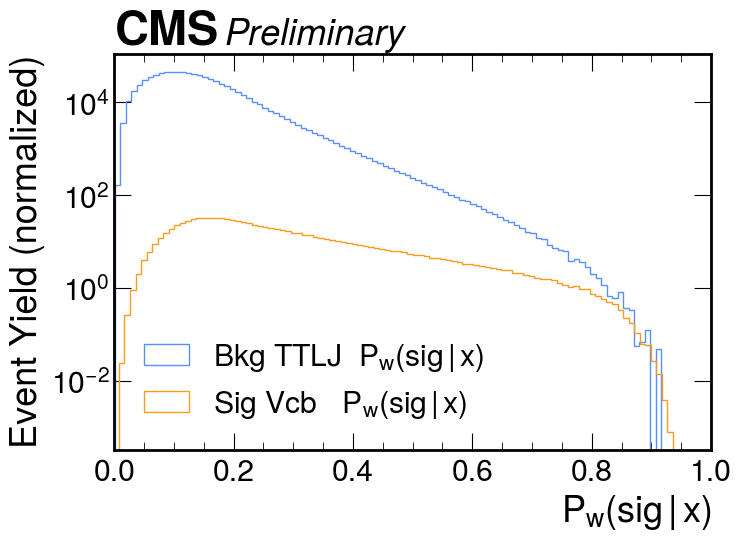

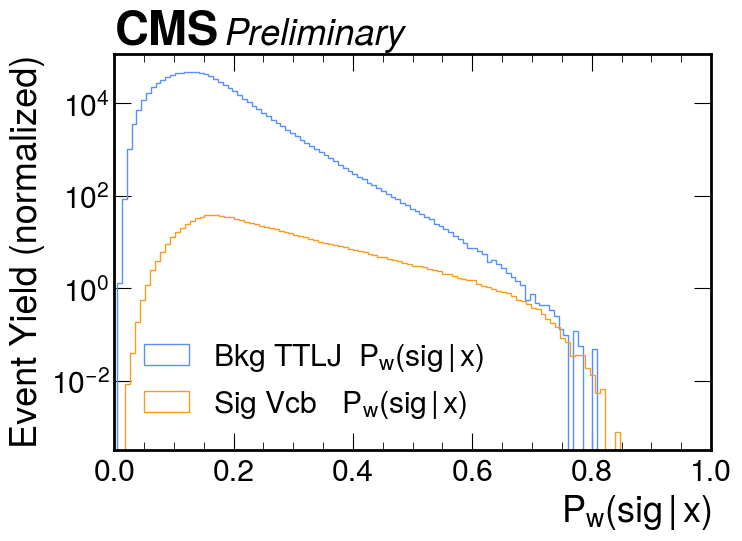

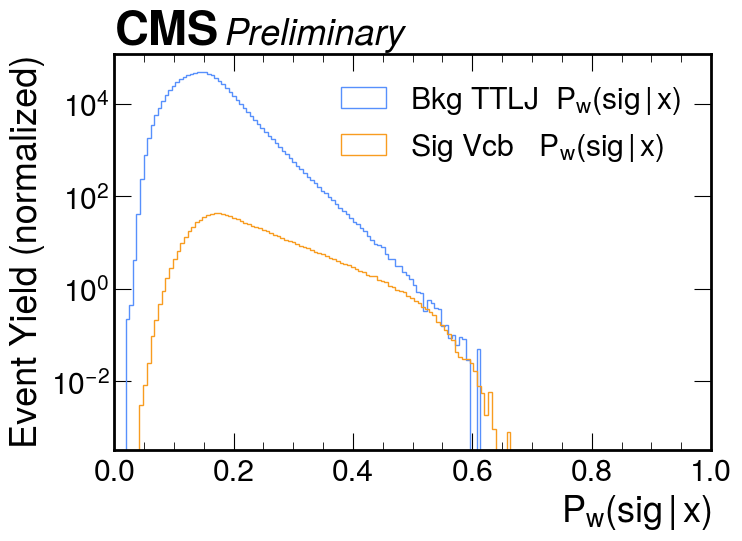

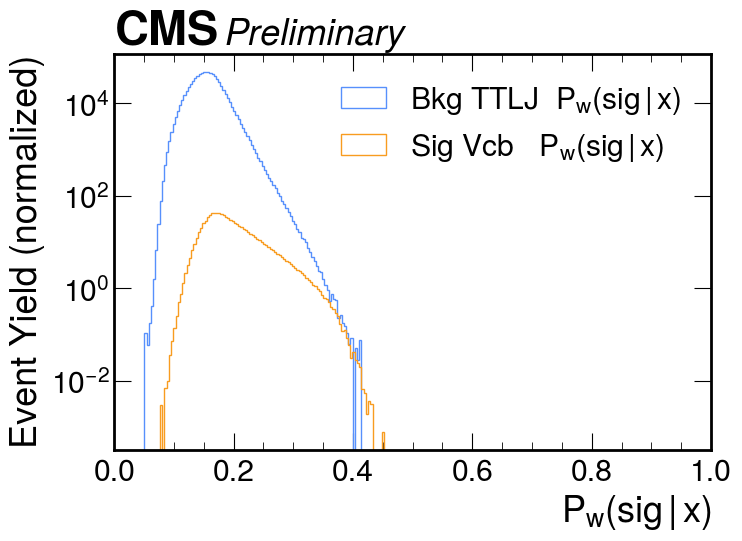

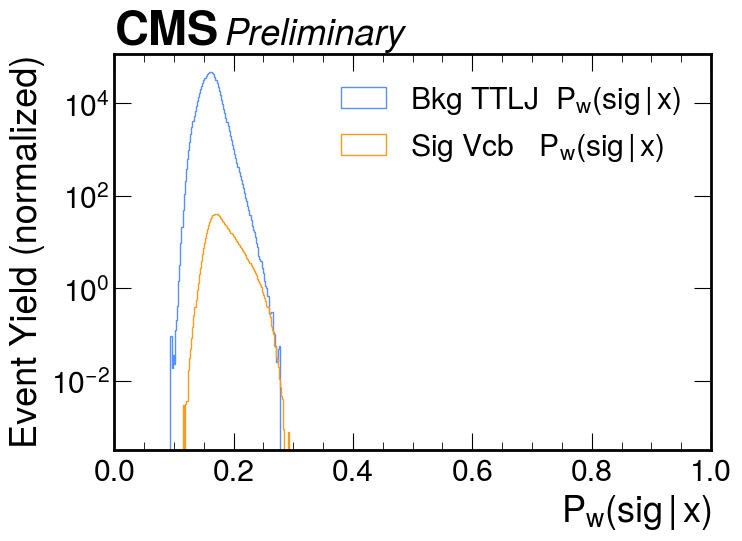

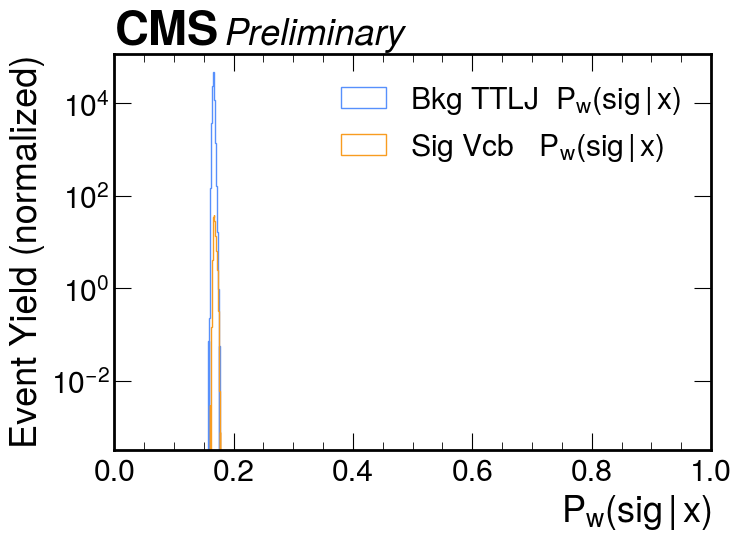

In [37]:
for T, p_v in prob_Vcb.items():
    p_b = prob_TTLJ[T]
    plot_signal_score(
        p_sig_v=p_v[:, 0], p_sig_b=p_b[:, 0],
        outdir='.',
        bins=100,
        thr=None,
        tag=f'T{T:.1f}',
        sig_idx=[0],
        use_mplhep=True,
        cms_label="Preliminary",
        data=False,
        year=2017,
        lumi=41.5,
        lumi_unit="fb$^{-1}$",
        figsize=(8,6),
        xlim=(0,1)
    )

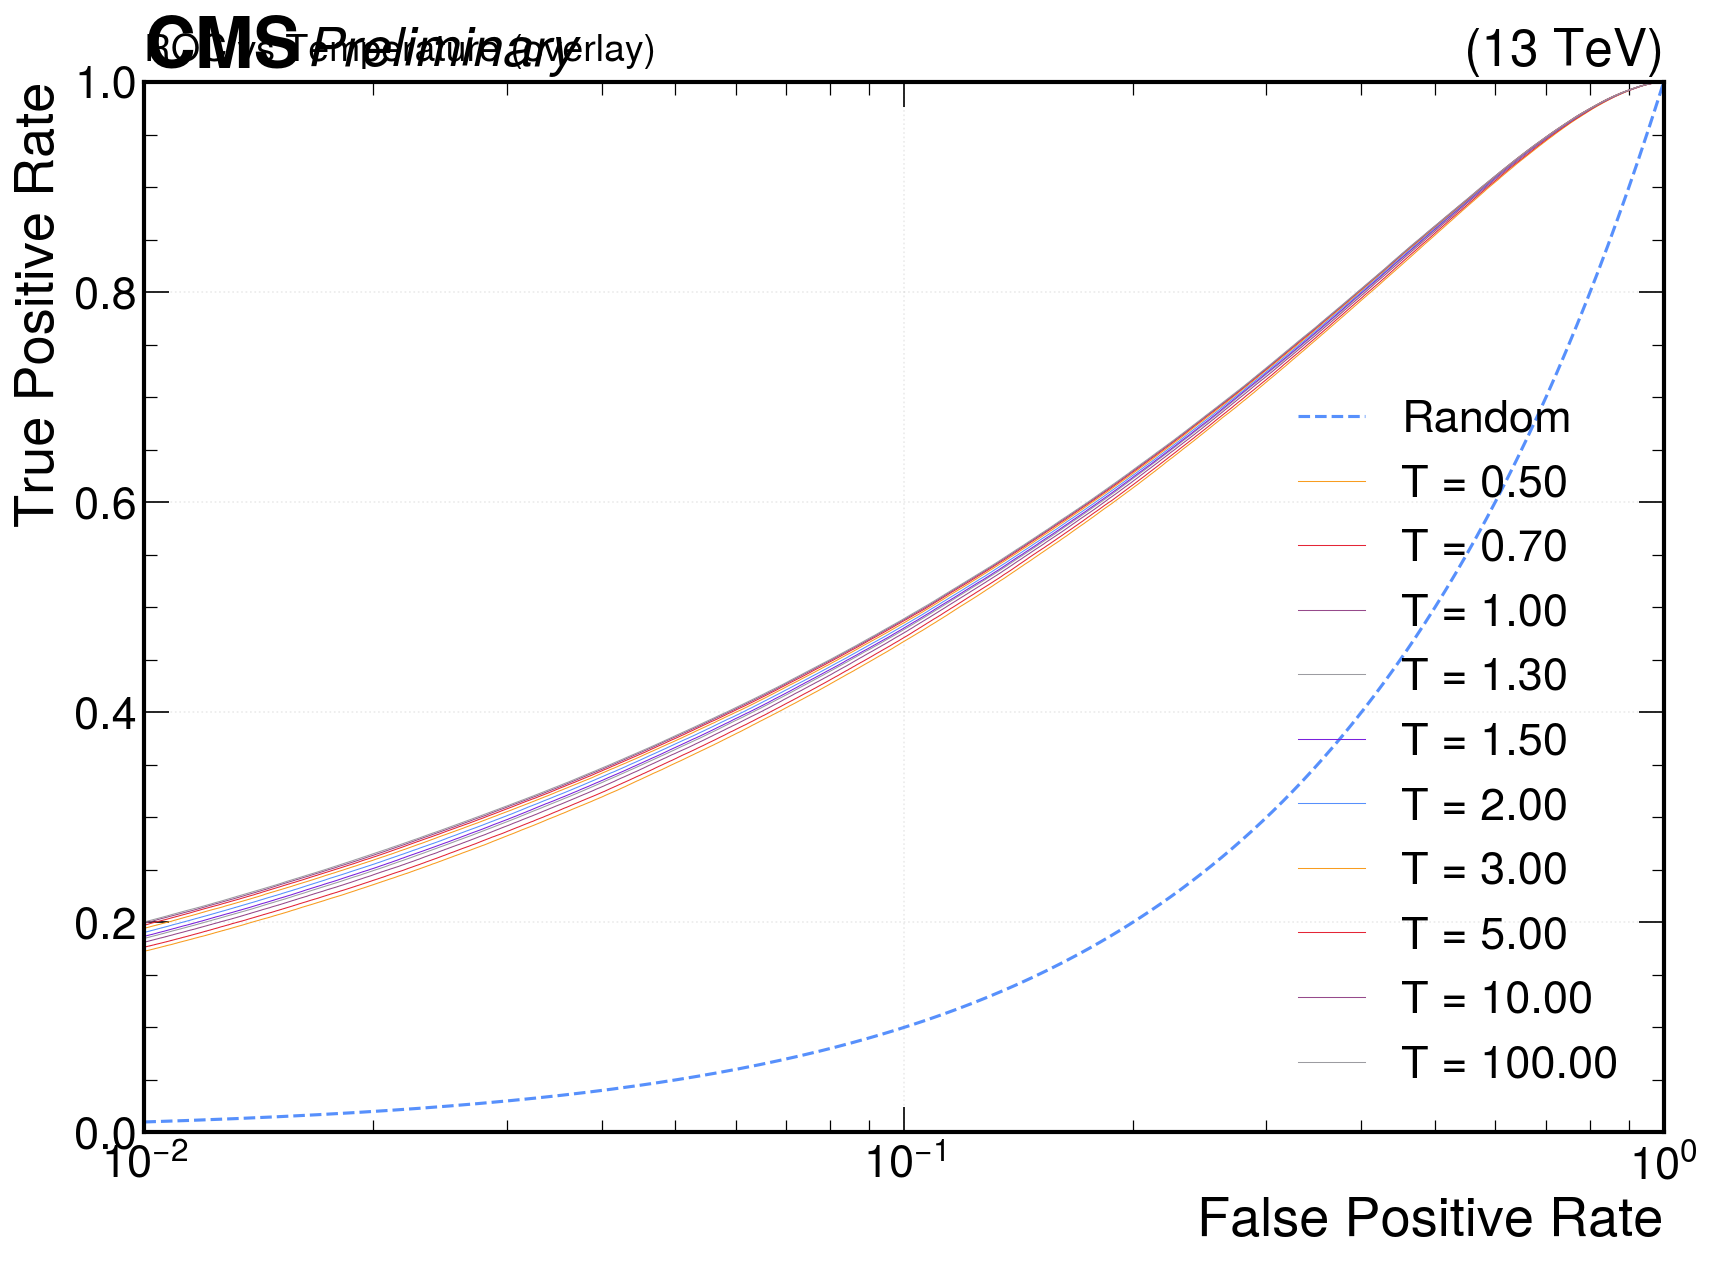

Temperature 0.50: AUC = 0.7866
Temperature 0.70: AUC = 0.7884
Temperature 1.00: AUC = 0.7905
Temperature 1.30: AUC = 0.7919
Temperature 1.50: AUC = 0.7926
Temperature 2.00: AUC = 0.7938
Temperature 3.00: AUC = 0.7949
Temperature 5.00: AUC = 0.7956
Temperature 10.00: AUC = 0.7961
Temperature 100.00: AUC = 0.7964


In [38]:
def ROC_AUC(score, y, plot_path, weight=None, fname="ROC.png", style="CMS",
            scale="linear", labels=None,
            title=None, subtitle=None,
            extra_text=None, extra_loc="upper left", extra_kwargs=None,
            legend_loc="lower right"):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, roc_auc_score
    try:
        import mplhep as hep
        hep.style.use(style)
    except Exception:
        pass

    # normalize inputs to list-of-series
    is_multi = isinstance(score, (list, tuple))
    if not is_multi:
        score_list  = [score]
        y_list      = [y]
        weight_list = [weight]
    else:
        score_list  = list(score)
        y_list      = list(y) if isinstance(y, (list, tuple)) else [y]*len(score_list)
        weight_list = list(weight) if isinstance(weight, (list, tuple)) else [weight]*len(score_list)

    # fallback colors if user constants are undefined
    try:
        BASELINE
    except NameError:
        BASELINE = "0.5"
    try:
        ROC_COLOR
    except NameError:
        ROC_COLOR = None  # let matplotlib choose

    fig, ax = plt.subplots(figsize=(12.0, 9.0), dpi=150)

    # random baseline
    if scale == "log":
        y = np.logspace(-2, 0, 300)
        ax.plot(y, y, ls="--", lw=1.5, label="Random")
    else:
        ax.plot([0, 1], [0, 1], ls="--", lw=1.5, label="Random")

    aucs = []
    for i, (s, yy, w) in enumerate(zip(score_list, y_list, weight_list)):
        s  = np.asarray(s, dtype=np.float32)
        yy = np.asarray(yy, dtype=np.int8)
        if w is not None:
            w = np.asarray(w, dtype=np.float64)
            mask = np.isfinite(s) & np.isfinite(yy) & np.isfinite(w) & (w > 0)
            s, yy, w = s[mask], yy[mask], w[mask]
        else:
            mask = np.isfinite(s) & np.isfinite(yy)
            s, yy = s[mask], yy[mask]
            w = None

        fpr, tpr, _ = roc_curve(yy, s, sample_weight=w, drop_intermediate=True)
        auc = roc_auc_score(yy, s, sample_weight=w)
        aucs.append(auc)

        lab = labels[i] if (labels and i < len(labels)) else (f"ROC (AUC = {auc:.3f})" if not is_multi else f"Fold {i} (AUC = {auc:.3f})")
        ax.plot(fpr, tpr, lw=0.5, label=lab)

    # axes cosmetics
    if scale == "log":
        ax.set_xscale("log")
        ax.set_xlim(1e-2, 1.0)
    else:
        ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.legend(frameon=False, loc=legend_loc)

    # CMS-like label (safe to skip if mplhep missing)
    try:
        hep.cms.label(llabel="Preliminary", data=False, com=13, ax=ax)
    except Exception:
        pass

    # Title & Subtitle
    if title:
        ax.set_title(title, loc="left", fontsize=18, pad=10)
        if subtitle:
            # subtitle를 제목 바로 아래에 살짝 작게
            ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=12)

    # Extra text (multi-line supported)
    if extra_text:
        if isinstance(extra_text, (list, tuple)):
            txt = "\n".join(map(str, extra_text))
        else:
            txt = str(extra_text)

        # 위치 해석
        loc_map = {
            "upper left":  (0.02, 0.98, "left",  "top"),
            "upper right": (0.98, 0.98, "right", "top"),
            "lower left":  (0.02, 0.02, "left",  "bottom"),
            "lower right": (0.98, 0.02, "right", "bottom"),
        }
        x, y, ha, va = loc_map.get(extra_loc, loc_map["upper left"])

        kw = dict(
            transform=ax.transAxes,
            ha=ha, va=va,
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.6)
        )
        if extra_kwargs:
            kw.update(extra_kwargs)

        ax.text(x, y, txt, **kw)

    plt.tight_layout()
    plt.show()
    return aucs if is_multi else aucs[0]


# 정렬된 온도 리스트
temps = sorted(prob_Vcb.keys())

# 리스트로 묶어서 한 번에 전달
scores  = []
ys      = []
weights = []
labels  = []

for T in temps:
    p_v = prob_Vcb[T]          # shape (Nv, K)
    p_b = prob_TTLJ[T]         # shape (Nb, K)

    s = np.concatenate([p_v[:, 0], p_b[:, 0]])
    y = np.concatenate([np.ones(len(p_v), dtype=np.int8),
                        np.zeros(len(p_b), dtype=np.int8)])
    w = np.concatenate([Vcb['weight_base'], TTLJ['weight_base']])

    scores.append(s)
    ys.append(y)
    weights.append(w)
    labels.append(f"T = {T:.2f}")

# 한 번의 호출로 오버레이 플롯 생성
aucs = ROC_AUC(
    score=scores,
    y=ys,
    weight=weights,
    plot_path=".",                 # 저장 기능 쓰려면 아래 '저장 패치' 적용 권장
    fname="ROC_overlay.png",
    style="CMS",
    scale="log",
    labels=labels,
    title="ROC vs Temperature (overlay)",
    legend_loc="lower right"
)

# AUC 출력
for T, auc in zip(temps, aucs):
    print(f"Temperature {T:.2f}: AUC = {auc:.4f}")

In [30]:
np.any(Vcb['weight_base'] < 0)

True